In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

TRAIN_PATH = "Dataset/train"
TEST_PATH  = "Dataset/test"
MODEL_PATH = "Model/model.xml"

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [23]:
def preprocess(img):
    img = cv2.resize(img, (100, 100))
    img = cv2.equalizeHist(img)
    return img

In [24]:
def detect_face(img):
    faces = face_cascade.detectMultiScale(img, 1.05, 2, minSize=(30, 30))
    if len(faces) > 0:
        x, y, w, h = faces[0]
        return preprocess(img[y:y+h, x:x+w]), (x, y, w, h)
    h, w = img.shape
    return preprocess(img), (0, 0, w, h)

In [25]:
def load_faces(folder_path, class_names):
    faces, labels = [], []
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path):
            continue
        for filename in sorted(os.listdir(class_path)):
            img = cv2.imread(os.path.join(class_path, filename), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            face_img, _ = detect_face(img)
            faces.append(face_img)
            labels.append(label)
    return faces, np.array(labels, dtype=np.int32)

In [26]:
def train_test_model():
    class_names = sorted(os.listdir(TRAIN_PATH))

    print("Loading training data...")
    train_faces, train_labels = load_faces(TRAIN_PATH, class_names)
    if not train_faces:
        print("No training data found!")
        return

    face_recognizer = cv2.face.LBPHFaceRecognizer_create()
    face_recognizer.train(train_faces, train_labels)

    print("Testing model...")
    test_faces, test_labels = load_faces(TEST_PATH, class_names)
    if not test_faces:
        print("No test data found!")
        return

    correct = 0
    for face, true_label in zip(test_faces, test_labels):
        predicted_label, confidence = face_recognizer.predict(face)
        status = "RIGHT" if predicted_label == true_label else "WRONG"
        correct += predicted_label == true_label
        print(f"Actual: {class_names[true_label]} | Predicted: {class_names[predicted_label]} | Confidence: {confidence:.2f} | {status}")

    print(f"\nAverage Accuracy: {correct / len(test_faces) * 100:.2f}%")

    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    face_recognizer.write(MODEL_PATH)
    print("Model saved successfully!")

In [ ]:
def predict(img_path):
    if not os.path.exists(MODEL_PATH):
        print("Error: Model not found. Train the model first!")
        return

    class_names = sorted(os.listdir(TRAIN_PATH))

    face_recognizer = cv2.face.LBPHFaceRecognizer_create()
    face_recognizer.read(MODEL_PATH)

    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Cannot read image at {img_path}")
        return

    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_img, (x, y, w, h) = detect_face(img_gray)
    predicted_label, confidence = face_recognizer.predict(face_img)
    predicted_class = class_names[predicted_label]

    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    cv2.putText(img, f"{predicted_class} | {confidence:.2f}", (x, y-10), cv2.FONT_HERSHEY_PLAIN, 1, (0, 255, 0))

    print(f"\n{img_path} detected as {predicted_class}")
    print(f"Detected Subject: {predicted_class}")
    print(f"Detected face location: x={x}, y={y}, w={w}, h={h}")
    print(f"Confidence: {confidence:.2f}")
    

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


===Face Recognition Menu===
1. Train and Test Model
2. Predict
3. Exit

/Users/fadh/Documents/BINUS/Semester 4/LAB AI Semester 4/LAB Computer Vision/LatihanQuizpt2/Dataset/test/s40/10.pgm detected as s40
Confidence: 66.03


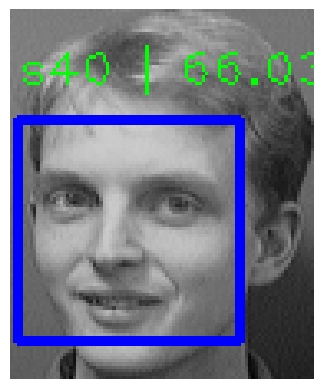


===Face Recognition Menu===
1. Train and Test Model
2. Predict
3. Exit
Exit...


In [28]:
def main():
    while True:
        print("\n===Face Recognition Menu===")
        print("1. Train and Test Model")
        print("2. Predict")
        print("3. Exit")
        choice = input("Enter your choice (1-3): ")
        if choice == '1':
            train_test_model()
        elif choice == '2':
            img_path = input("Enter the path to the image for testing (absolute path): ")
            predict(img_path)
        elif choice == '3':
            print("Exit...")
            break
        else:
            print("Invalid Input. Please Choice (1-3)!")
        
main()
